In [1]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [3]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog, airFogWithNMSE

In [4]:
#Import data
import pandas as pd
import json

df = pd.read_csv('../AirFogSim/output/global_data.csv')
data = df.to_dict(orient='list')

all_keys = list(data.keys())
all_values = list(data.values())

with open('../AirFogSim/output/context_summary.json', 'r') as f:
    context_summary = json.load(f)

y1 = all_values[7][1:]  # compute_load_avg
x11 = all_values[1][:len(y1)]   # current_task_success_ratio
x12 = all_values[8][:len(y1)]   # current_vehicle_density
x13 = all_values[9][:len(y1)]   # current_uav_density
x14 = all_values[10][:len(y1)]  # junction_0_vehicle_count
x15 = all_values[11][:len(y1)]  # junction_1_vehicle_count
x16 = all_values[12][:len(y1)]  # junction_2_vehicle_count

y2 = all_values[4][1:]  # avg_V2U_rate
x21 = all_values[8][:len(y2)]   # current_vehicle_density
x22 = all_values[9][:len(y2)]   # current_uav_density
x23 = all_values[7][:len(y2)]  # current_compute_load_avg

y3 = all_values[1][1:]  # task_success_ratio
x31 = all_values[4][:len(y3)]   # current_avg_V2U_rate
x32 = all_values[5][:len(y3)]   # current_avg_V2I_rate
x33 = all_values[7][:len(y3)]   # current_compute_load_avg

y4 = all_values[9][1:]  # uav_density
x41 = all_values[6][:len(y4)]   # current_avg_U2I_rate
x42 = all_values[7][:len(y4)]  # current_compute_load_avg
x43 = [context_summary["nonfly_zones"]["area_ratio"]] * len(y4)    # nonfly_zones.area_ratio

dep_vars = list(map(str, [y1, y2, y3, y4]))
indep_vars = list(map(list, (map(str, [x11, x12, x13, x14, x15, x16]),
                                map(str, [x21, x22, x23]),
                                map(str, [x31, x32, x33]),
                                map(str, [x41, x42, x43]))))

In [5]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 4 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.

Pattern 4: Predict the UAV density of the next time slot based on the current average U2I rate, compute load and nonfly zone area ratio.
- Independent variable (x1): Current average U2I rate.
- Independent variable (x2): Current average compute load.
- Independent variable (x3): Nonfly zone area ratio.
- Dependent variable (y): UAV density of the next time slot.
"""

In [6]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehicle counts.
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot
Note: Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacity per node (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs.

Pattern 4: Predict the UAV density of the next time slot based on the current average U2I rate, compute load and nonfly zone area ratio.
- Independent variable (x1): Current average U2I rate.
- Independent variable (x2): Current average compute load.
- Independent variable (x3): Nonfly zone area ratio.
- Dependent variable (y): UAV density of the next time slot
Note: UAV density is constrained by the presence of two non-fly zones (totaling 80,000 m² or ~1.1% of the area), which limit the available flight space and cause spatial redistribution of UAVs.
"""

Running experiment 1...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: 
- The dataset for this pattern shows the average compute load of the next time slot as the dependent variable. The independent variables include current task success ratio, vehicle density, UAV density, and vehicle counts at specific junctions. 
- The data shows some variations and patterns, indicating a non-linear relationship between the dependent and independent variables.
- The task success ratio (x1) might be inversely related to the compute load as a higher success ratio could imply lesser residual tasks requiring computation.
- The vehicle density (x2) and junction vehicle counts (x4, x5, x6) are likely to increase the compute load due to higher task generation rates.
- The expressions should capture these influences concisely.

Pattern 2: 
- Here, the dependent variable is the average V2U rate. The independent variables are vehicle density, UAV density, and compute load

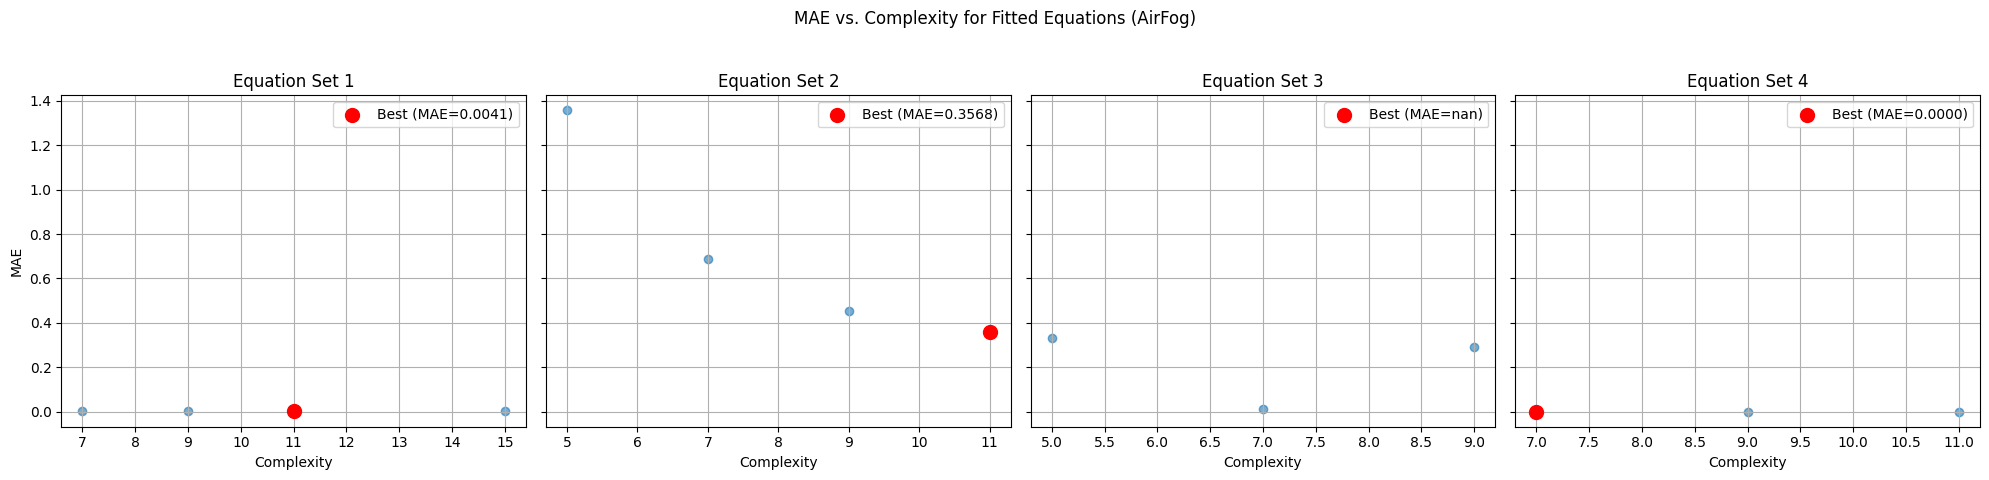

Experiment 1 finished.
Running experiment 2...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: 
The dependent variable y (average compute load) seems to have a strong correlation with the independent variables provided. The task success ratio (x1) and vehicle density (x2) are likely to be significant contributors to compute load, as they directly impact the number of tasks and the computational resources required. Additionally, the UAV density (x3) might affect compute load due to communication overheads. Junction vehicle counts (x4, x5, x6) could indicate congestion, which may impact computational resources indirectly.

To predict the average compute load, we can start by examining simple linear and polynomial relationships between y and the independent variables. Given that y is small, we may explore expressions involving the square or cube of the independent variables to capture any non-linear impact.

Pattern 2: 
The dependent variable y (averag

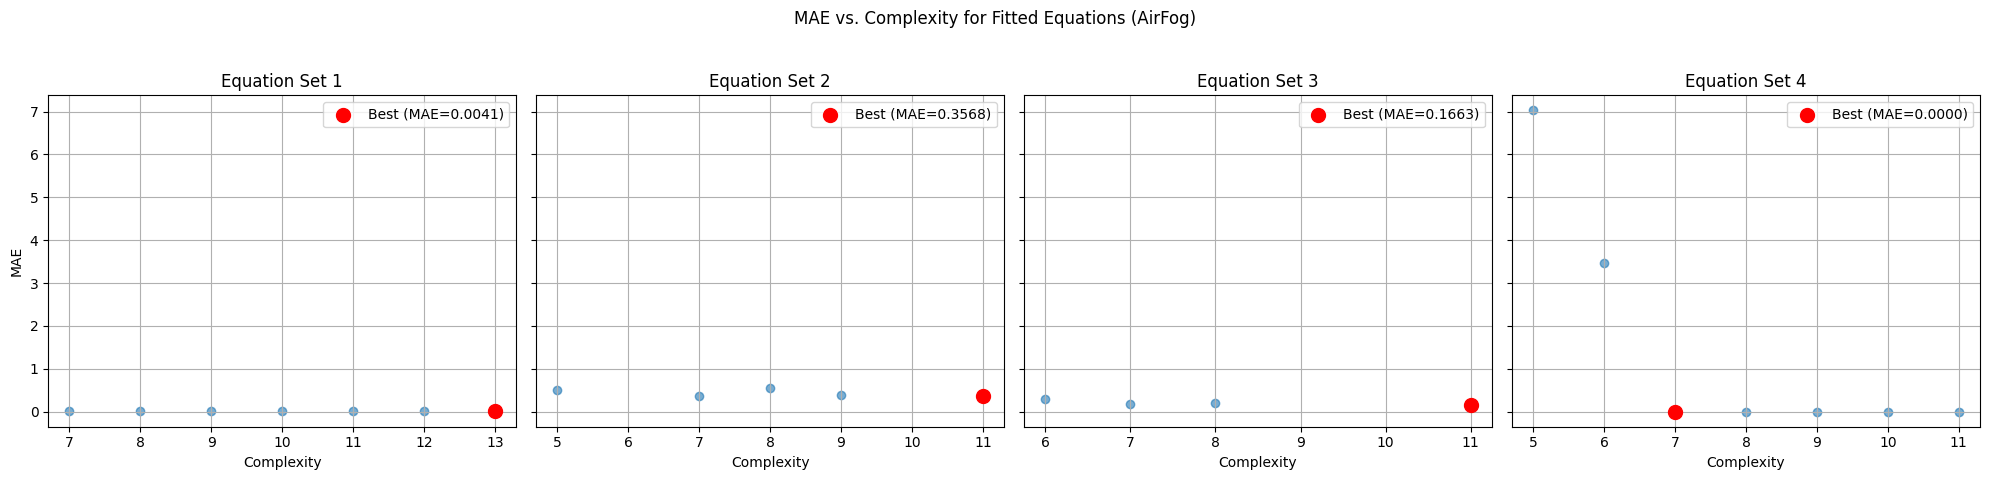

Experiment 2 finished.
Running experiment 3...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1 Analysis:
- The dependent variable y (average compute load) seems to be influenced by x1 (task success ratio), x2 (vehicle density), and x4 (Junction 0 vehicle count). 
- x3 (UAV density) and x5 (Junction 1 vehicle count) might have secondary effects but less pronounced.
- A polynomial relationship or a combination of these variables with simple operators might model this pattern well.
- Consider expressions involving multiplication, addition, or combination with squares or cubes.

Pattern 2 Analysis:
- The dependent variable y (average V2U rate) appears to be influenced by x1 (vehicle density) and x3 (average compute load).
- Since x2 (UAV density) is constant, it might not contribute much to the variation.
- A linear or quadratic relationship between vehicle density and compute load could help capture the pattern.
- Explore expressions using multiplicatio

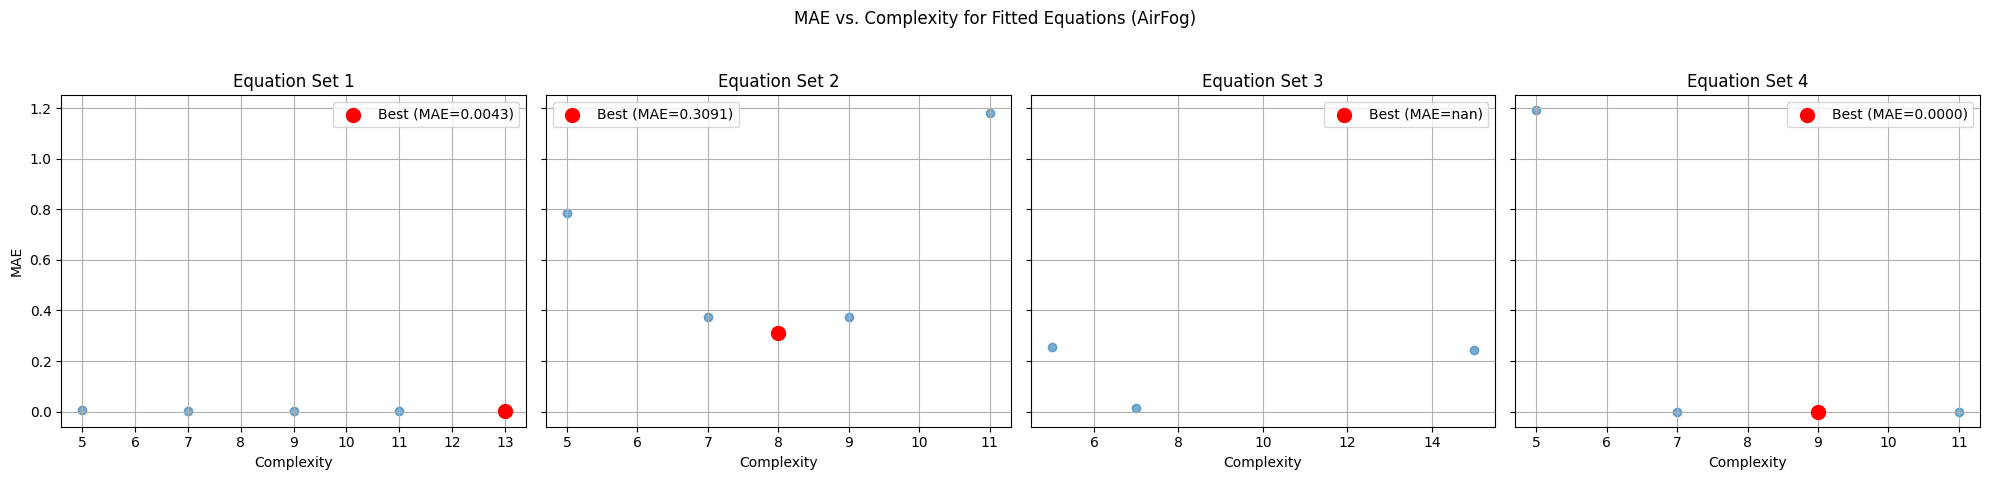

Experiment 3 finished.


In [8]:
# Using MAE as the error function

import json
import os # Ensure os is imported if not already in this cell
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    current_run_data_for_accumulator = {
        'CombResults': results
    }
    results_fromAllruns.append(current_run_data_for_accumulator)
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "tests/AirFog"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    # Prepare data for JSON output for the current run
    run_output_data = {
        "run_number": i + 1,
        "final_results": results  # CombResults for this run
    }

    with open(f"{directory_path}/run{i+1}_mae.json", 'w') as f:
        json.dump(run_output_data, f, indent=2)

In [ ]:
# Using fitness function with NMSE as the error function

import json
import os # Ensure os is imported if not already in this cell
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns_nmse = []  # Using a different name to avoid conflict if run in the same session
iteration_infos_fromAllruns_nmse = [] # Using a different name


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1} (NMSE)...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFogWithNMSE(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    current_run_data_for_accumulator = {
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    }
    results_fromAllruns_nmse.append(current_run_data_for_accumulator)
    
    # Store the iteration info
    iteration_infos_fromAllruns_nmse.append(iteration_info)

    # print(f"Experiment {i+1} (NMSE) finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} (NMSE) finished.")

    directory_path = "tests/AirFog"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    # PromptsUsed.txt will be overwritten if MAE block was run before, content is same though
    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    # Prepare data for JSON output for the current run
    run_output_data = {
        "run_number": i + 1,
        "final_results": results,  # CombResults for this run
        "all_expressions": all_expressions,
        "usage_list": usage_list,
        "total_chain_run_time_seconds": total_chain_run_time,
        "LLM_raw_expressions": all_expressionsLLM,
        "iteration_information": iteration_info
        # "cost": experiment.cost() # Uncomment if cost is being calculated and needed
    }

    with open(f"{directory_path}/run{i+1}_nmse.json", 'w') as f:
        json.dump(run_output_data, f, indent=2)